# Оптимизация производственных расходов металлургического комбината

**Содержание**
1. [Описание данных](#Описание-данных:)
2. [Изучение данных](#Изучение-данных:)
3. [Обучение на различных наборах признаков](#Обучение-на-различных-наборах-признаков)
4. [Модели на очищенных от выбросов данных](#Модели-на-очищенных-от-выбросов-данных)
5. [Дополнительные модели](#Дополнительные-модели)
6. [Визуализация с TSNE](#Визуализация-с-TSNE-очищенного-от-выбросов-датафрейма-(раскраска-по-диапазону-начальной-температуры))
7. [Вывод](#Вывод:)

## Описание данных:
Чтобы оптимизировать производственные расходы, металлургический комбинат решил уменьшить потребление электроэнергии на этапе обработки стали. Нужно построить модель для предсказания температуры стали.

### Описание этапа обработки

Сталь обрабатывают в металлическом ковше вместимостью около 100 тонн. Чтобы ковш выдерживал высокие температуры, изнутри его облицовывают огнеупорным кирпичом. Расплавленную сталь заливают в ковш и подогревают до нужной температуры графитовыми электродами. Они установлены в крышке ковша. 

Из сплава выводится сера (десульфурация), добавлением примесей корректируется химический состав и отбираются пробы. Сталь легируют — изменяют её состав — подавая куски сплава из бункера для сыпучих материалов или проволоку через специальный трайб-аппарат (англ. tribe, «масса»).

Перед тем как первый раз ввести легирующие добавки, измеряют температуру стали и производят её химический анализ. Потом температуру на несколько минут повышают, добавляют легирующие материалы и продувают сплав инертным газом. Затем его перемешивают и снова проводят измерения. Такой цикл повторяется до достижения целевого химического состава и оптимальной температуры плавки.

Тогда расплавленная сталь отправляется на доводку металла или поступает в машину непрерывной разливки. Оттуда готовый продукт выходит в виде заготовок-слябов (англ. *slab*, «плита»).

### Описание данных

Данные состоят из файлов, полученных из разных источников:

- `data_arc.csv` — данные об электродах;
- `data_bulk.csv` — данные о подаче сыпучих материалов (объём);
- `data_bulk_time.csv` *—* данные о подаче сыпучих материалов (время);
- `data_gas.csv` — данные о продувке сплава газом;
- `data_temp.csv` — результаты измерения температуры;
- `data_wire.csv` — данные о проволочных материалах (объём);
- `data_wire_time.csv` — данные о проволочных материалах (время).


## Изучение данных:

In [1]:
import os

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics import mean_absolute_error

### Изучаем данные по таблице data_arc

In [2]:
def load_dataset(name, **kwargs):
    """Читает датасет из локальной папки datasets/, при её отсутствии — с code.s3.yandex.net."""
    local = os.path.join('datasets', name)
    source = local if os.path.exists(local) else 'https://code.s3.yandex.net/datasets/' + name
    return pd.read_csv(source, **kwargs)

data_arc = load_dataset('data_arc_new.csv')
data_arc.head()

,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691


In [3]:
pd.Series(data_arc['key'].unique()).count()

np.int64(3214)

In [4]:
data_arc.info()

<class 'pandas.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   key                   14876 non-null  int64  
 1   Начало нагрева дугой  14876 non-null  str    
 2   Конец нагрева дугой   14876 non-null  str    
 3   Активная мощность     14876 non-null  float64
 4   Реактивная мощность   14876 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 581.2 KB


In [5]:
data_arc['Начало нагрева дугой'] = pd.to_datetime(data_arc['Начало нагрева дугой'])
data_arc['Конец нагрева дугой'] = pd.to_datetime(data_arc['Конец нагрева дугой'])

In [6]:
data_arc['diff'] = (data_arc['Конец нагрева дугой'] - data_arc['Начало нагрева дугой'])
data_arc['diff'] = data_arc['diff'].dt.seconds

In [7]:
data_arc.describe()

,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность,diff
count,14876.000000,14876,14876,14876.000000,14876.000000,14876.000000
mean,1615.220422,2019-07-05 12:25:51.921081,2019-07-05 12:28:43.592027,0.662752,0.438986,171.670946
min,1.000000,2019-05-03 11:02:14,2019-05-03 11:06:02,0.223120,-715.479924,11.000000
25%,806.000000,2019-06-03 23:18:23.250000,2019-06-03 23:21:35,0.467115,0.337175,107.000000
50%,1617.000000,2019-07-03 01:31:26.500000,2019-07-03 01:35:13,0.599587,0.441639,147.000000
75%,2429.000000,2019-08-07 22:52:20.750000,2019-08-07 22:56:47,0.830070,0.608201,214.000000
max,3241.000000,2019-09-06 17:24:54,2019-09-06 17:26:15,1.463773,1.270284,907.000000
std,934.571502,NaN,NaN,0.258885,5.873485,98.186803


При похожих средних значениях у реактивной мощности стандартное отклонение заметно выше, чем у активной; у обеих мощностей минимальные и максимальные значения по модулю превышают утроенное стандартное отклонение. Подготовим функцию `filt` для квантильной фильтрации выбросов — применим её к сводной таблице в разделе про очищенные данные:

In [8]:
def filt(l, h, df, features):
    for i in features:
        low =  df[i].quantile(l)
        high = df[i].quantile(h)

        df = df[(df[i]>= low) & (df[i]<= high)]

    return df

In [9]:
data_arc.info()

<class 'pandas.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   key                   14876 non-null  int64         
 1   Начало нагрева дугой  14876 non-null  datetime64[us]
 2   Конец нагрева дугой   14876 non-null  datetime64[us]
 3   Активная мощность     14876 non-null  float64       
 4   Реактивная мощность   14876 non-null  float64       
 5   diff                  14876 non-null  int32         
dtypes: datetime64[us](2), float64(2), int32(1), int64(1)
memory usage: 639.3 KB


### Изучаем данные по таблице data_bulk

In [10]:
data_bulk = load_dataset('data_bulk_new.csv')
data_bulk.head()

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaN,NaN,NaN,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,150.0,154.0
1,2,NaN,NaN,NaN,73.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,149.0,154.0
2,3,NaN,NaN,NaN,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205.0,NaN,152.0,153.0
3,4,NaN,NaN,NaN,81.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,207.0,NaN,153.0,154.0
4,5,NaN,NaN,NaN,78.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,203.0,NaN,151.0,152.0


In [11]:
data_bulk.info()

<class 'pandas.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   key      3129 non-null   int64  
 1   Bulk 1   252 non-null    float64
 2   Bulk 2   22 non-null     float64
 3   Bulk 3   1298 non-null   float64
 4   Bulk 4   1014 non-null   float64
 5   Bulk 5   77 non-null     float64
 6   Bulk 6   576 non-null    float64
 7   Bulk 7   25 non-null     float64
 8   Bulk 8   1 non-null      float64
 9   Bulk 9   19 non-null     float64
 10  Bulk 10  176 non-null    float64
 11  Bulk 11  177 non-null    float64
 12  Bulk 12  2450 non-null   float64
 13  Bulk 13  18 non-null     float64
 14  Bulk 14  2806 non-null   float64
 15  Bulk 15  2248 non-null   float64
dtypes: float64(15), int64(1)
memory usage: 391.3 KB


In [12]:
pd.Series(data_bulk['key'].unique()).count()

np.int64(3129)

In [13]:
data_bulk.describe()

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
count,3129.000000,252.000000,22.000000,1298.000000,1014.000000,77.000000,576.000000,25.000000,1.0,19.000000,176.000000,177.000000,2450.000000,18.000000,2806.000000,2248.000000
mean,1624.383509,39.242063,253.045455,113.879045,104.394477,107.025974,118.925347,305.600000,49.0,76.315789,83.284091,76.819209,260.471020,181.111111,170.284747,160.513345
std,933.337642,18.277654,21.180578,75.483494,48.184126,81.790646,72.057776,191.022904,NaN,21.720581,26.060347,59.655365,120.649269,46.088009,65.868652,51.765319
min,1.000000,10.000000,228.000000,6.000000,12.000000,11.000000,17.000000,47.000000,49.0,63.000000,24.000000,8.000000,53.000000,151.000000,16.000000,1.000000
25%,816.000000,27.000000,242.000000,58.000000,72.000000,70.000000,69.750000,155.000000,49.0,66.000000,64.000000,25.000000,204.000000,153.250000,119.000000,105.000000
50%,1622.000000,31.000000,251.500000,97.500000,102.000000,86.000000,100.000000,298.000000,49.0,68.000000,86.500000,64.000000,208.000000,155.500000,151.000000,160.000000
75%,2431.000000,46.000000,257.750000,152.000000,133.000000,132.000000,157.000000,406.000000,49.0,70.500000,102.000000,106.000000,316.000000,203.500000,205.750000,205.000000
max,3241.000000,185.000000,325.000000,454.000000,281.000000,603.000000,503.000000,772.000000,49.0,147.000000,159.000000,313.000000,1849.000000,305.000000,636.000000,405.000000


<Axes: >

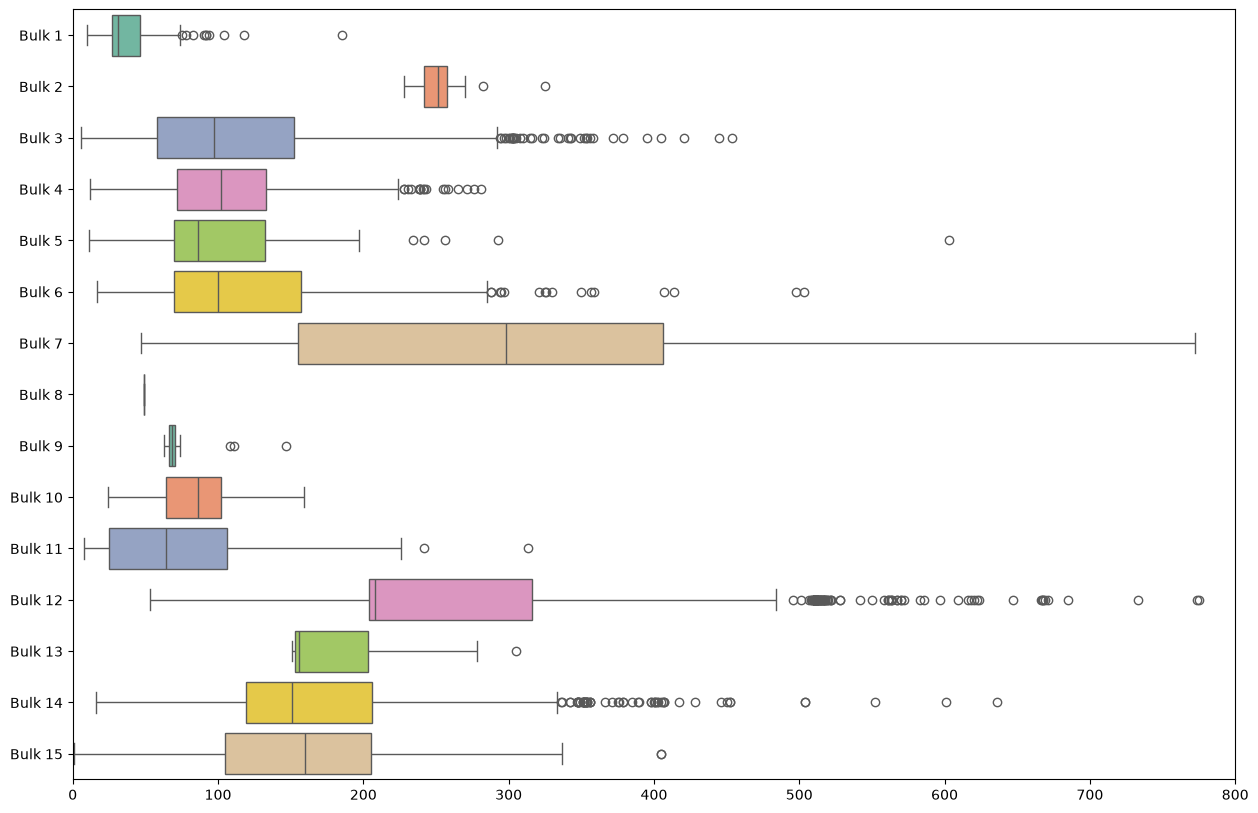

In [14]:
plt.figure(figsize=(15,10))
plt.xlim(0, 800)
sns.boxplot(data=data_bulk.drop('key', axis=1), orient="h", palette="Set2")

Видим, что у всех bulk распределения различны.

In [15]:
data_bulk = data_bulk.fillna(0)

Фильтрацию не проводим, т.к. исходный датасет имел много пропусков.

### Изучаем данные по таблице data_bulk_time

In [16]:
data_bulk_time = load_dataset('data_bulk_time_new.csv')
data_bulk_time.head()

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaN,NaN,NaN,2019-05-03 11:28:48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 11:24:31,NaN,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2,NaN,NaN,NaN,2019-05-03 11:36:50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 11:53:30,NaN,2019-05-03 11:48:37,2019-05-03 11:44:39
2,3,NaN,NaN,NaN,2019-05-03 12:32:39,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 12:27:13,NaN,2019-05-03 12:21:01,2019-05-03 12:16:16
3,4,NaN,NaN,NaN,2019-05-03 12:43:22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 12:58:00,NaN,2019-05-03 12:51:11,2019-05-03 12:46:36
4,5,NaN,NaN,NaN,2019-05-03 13:30:47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 13:30:47,NaN,2019-05-03 13:34:12,2019-05-03 13:30:47


In [17]:
for i in data_bulk_time.columns[1:]:    
    data_bulk_time = data_bulk_time.rename(columns={i:i+'_t'})

In [18]:
pd.Series(data_bulk_time['key'].unique()).count()

np.int64(3129)

In [19]:
data_bulk_time.info()

<class 'pandas.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   key        3129 non-null   int64
 1   Bulk 1_t   252 non-null    str  
 2   Bulk 2_t   22 non-null     str  
 3   Bulk 3_t   1298 non-null   str  
 4   Bulk 4_t   1014 non-null   str  
 5   Bulk 5_t   77 non-null     str  
 6   Bulk 6_t   576 non-null    str  
 7   Bulk 7_t   25 non-null     str  
 8   Bulk 8_t   1 non-null      str  
 9   Bulk 9_t   19 non-null     str  
 10  Bulk 10_t  176 non-null    str  
 11  Bulk 11_t  177 non-null    str  
 12  Bulk 12_t  2450 non-null   str  
 13  Bulk 13_t  18 non-null     str  
 14  Bulk 14_t  2806 non-null   str  
 15  Bulk 15_t  2248 non-null   str  
dtypes: int64(1), str(15)
memory usage: 391.3 KB


In [20]:
for col in data_bulk_time.columns[1:]:
    data_bulk_time[col] = pd.to_datetime(data_bulk_time[col])

In [21]:
data_bulk_time.head()

,key,Bulk 1_t,Bulk 2_t,Bulk 3_t,Bulk 4_t,Bulk 5_t,Bulk 6_t,Bulk 7_t,Bulk 8_t,Bulk 9_t,Bulk 10_t,Bulk 11_t,Bulk 12_t,Bulk 13_t,Bulk 14_t,Bulk 15_t
0,1,NaT,NaT,NaT,2019-05-03 11:28:48,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:24:31,NaT,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2,NaT,NaT,NaT,2019-05-03 11:36:50,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:53:30,NaT,2019-05-03 11:48:37,2019-05-03 11:44:39
2,3,NaT,NaT,NaT,2019-05-03 12:32:39,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 12:27:13,NaT,2019-05-03 12:21:01,2019-05-03 12:16:16
3,4,NaT,NaT,NaT,2019-05-03 12:43:22,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 12:58:00,NaT,2019-05-03 12:51:11,2019-05-03 12:46:36
4,5,NaT,NaT,NaT,2019-05-03 13:30:47,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 13:30:47,NaT,2019-05-03 13:34:12,2019-05-03 13:30:47


### Изучаем данные по таблице data_gas

In [22]:
data_gas = load_dataset('data_gas_new.csv')
data_gas.head()

,key,Газ 1
0,1,29.749986
1,2,12.555561
2,3,28.554793
3,4,18.841219
4,5,5.413692


In [23]:
data_gas.info()

<class 'pandas.DataFrame'>
RangeIndex: 3239 entries, 0 to 3238
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3239 non-null   int64  
 1   Газ 1   3239 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 50.7 KB


In [24]:
pd.Series(data_gas['key'].unique()).count()

np.int64(3239)

In [25]:
data_gas.describe()

,key,Газ 1
count,3239.000000,3239.000000
mean,1621.861377,11.002062
std,935.386334,6.220327
min,1.000000,0.008399
25%,812.500000,7.043089
50%,1622.000000,9.836267
75%,2431.500000,13.769915
max,3241.000000,77.995040


<Axes: xlabel='Газ 1', ylabel='Count'>

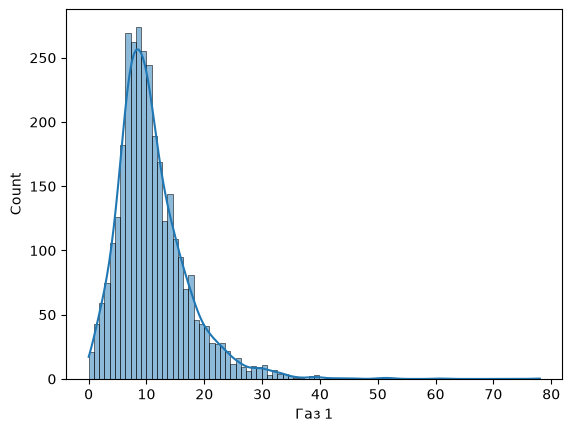

In [26]:
sns.histplot(data_gas['Газ 1'], kde=True)

### Изучаем данные по таблице data_temp

In [27]:
data_temp = load_dataset('data_temp_new.csv')
data_temp.head(6)

,key,Время замера,Температура
0,1,2019-05-03 11:02:04,1571.0
1,1,2019-05-03 11:07:18,1604.0
2,1,2019-05-03 11:11:34,1618.0
3,1,2019-05-03 11:18:04,1601.0
4,1,2019-05-03 11:25:59,1606.0
5,1,2019-05-03 11:30:38,1613.0


In [28]:
data_temp.info()

<class 'pandas.DataFrame'>
RangeIndex: 18092 entries, 0 to 18091
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   key           18092 non-null  int64  
 1   Время замера  18092 non-null  str    
 2   Температура   14665 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 424.2 KB


In [29]:
data_temp['Время замера'] = pd.to_datetime(data_temp['Время замера'])

In [30]:
(data_temp.groupby('key')['Температура'].sum() == 0).value_counts()

Температура
False    3216
Name: count, dtype: int64

In [31]:
pd.Series(data_temp['key'].unique()).count()

np.int64(3216)

In [32]:
round(len(data_temp) / data_temp['key'].nunique())

6

На одну партию имеем в среднем 4 замера температуры.

In [33]:
data_temp.loc[:4, 'Температура'].min()

np.float64(1571.0)

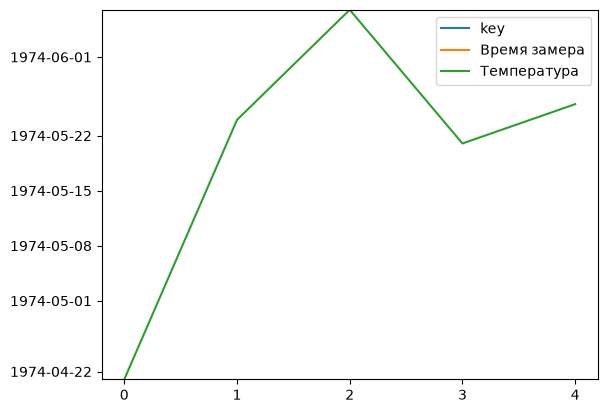

In [34]:
import matplotlib.ticker as ticker
y_min = data_temp.loc[:4, 'Температура'].min()
y_max = data_temp.loc[:4, 'Температура'].max()
ax = data_temp.head().plot()
plt.ylim(y_min, y_max)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))

In [35]:
data_temp.describe()

,key,Время замера,Температура
count,18092.000000,18092,14665.000000
mean,1616.460977,2019-07-05 13:36:58.791620,1590.722741
min,1.000000,2019-05-03 11:02:04,1191.000000
25%,807.750000,2019-06-04 00:35:01.250000,1580.000000
50%,1618.000000,2019-07-03 02:11:48,1590.000000
75%,2429.000000,2019-08-07 23:10:05.250000,1599.000000
max,3241.000000,2019-09-06 17:30:05,1705.000000
std,934.641385,NaN,20.394381


<Axes: xlabel='Температура', ylabel='Count'>

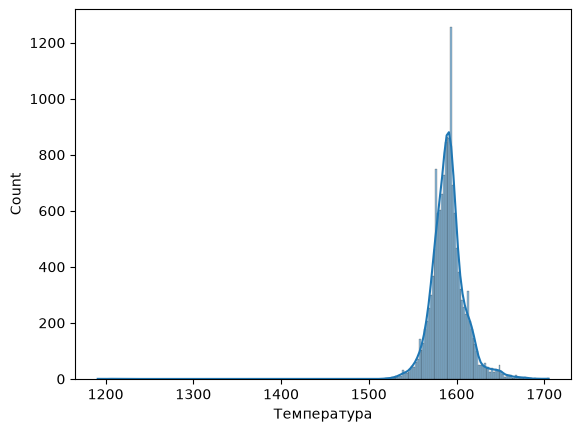

In [36]:
sns.histplot(data_temp['Температура'].dropna(), kde=True)

### Изучаем данные по таблице data_wire

In [37]:
data_wire = load_dataset('data_wire_new.csv')
data_wire.head()

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,60.059998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,96.052315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,91.160157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,89.063515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,89.238236,9.11456,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
data_wire.info()

<class 'pandas.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3081 non-null   int64  
 1   Wire 1  3055 non-null   float64
 2   Wire 2  1079 non-null   float64
 3   Wire 3  63 non-null     float64
 4   Wire 4  14 non-null     float64
 5   Wire 5  1 non-null      float64
 6   Wire 6  73 non-null     float64
 7   Wire 7  11 non-null     float64
 8   Wire 8  19 non-null     float64
 9   Wire 9  29 non-null     float64
dtypes: float64(9), int64(1)
memory usage: 240.8 KB


In [39]:
pd.Series(data_wire['key'].unique()).count()

np.int64(3081)

In [40]:
data_wire.describe()

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
count,3081.000000,3055.000000,1079.000000,63.000000,14.000000,1.000,73.000000,11.000000,19.000000,29.000000
mean,1623.426485,100.895853,50.577323,189.482681,57.442841,15.132,48.016974,10.039007,53.625193,34.155752
std,932.996726,42.012518,39.320216,99.513444,28.824667,NaN,33.919845,8.610584,16.881728,19.931616
min,1.000000,1.918800,0.030160,0.144144,24.148801,15.132,0.034320,0.234208,45.076721,4.622800
25%,823.000000,72.115684,20.193680,95.135044,40.807002,15.132,25.053600,6.762756,46.094879,22.058401
50%,1619.000000,100.158234,40.142956,235.194977,45.234282,15.132,42.076324,9.017009,46.279999,30.066399
75%,2434.000000,126.060483,70.227558,276.252014,76.124619,15.132,64.212723,11.886057,48.089603,43.862003
max,3241.000000,330.314424,282.780152,385.008668,113.231044,15.132,180.454575,32.847674,102.762401,90.053604


<Axes: >

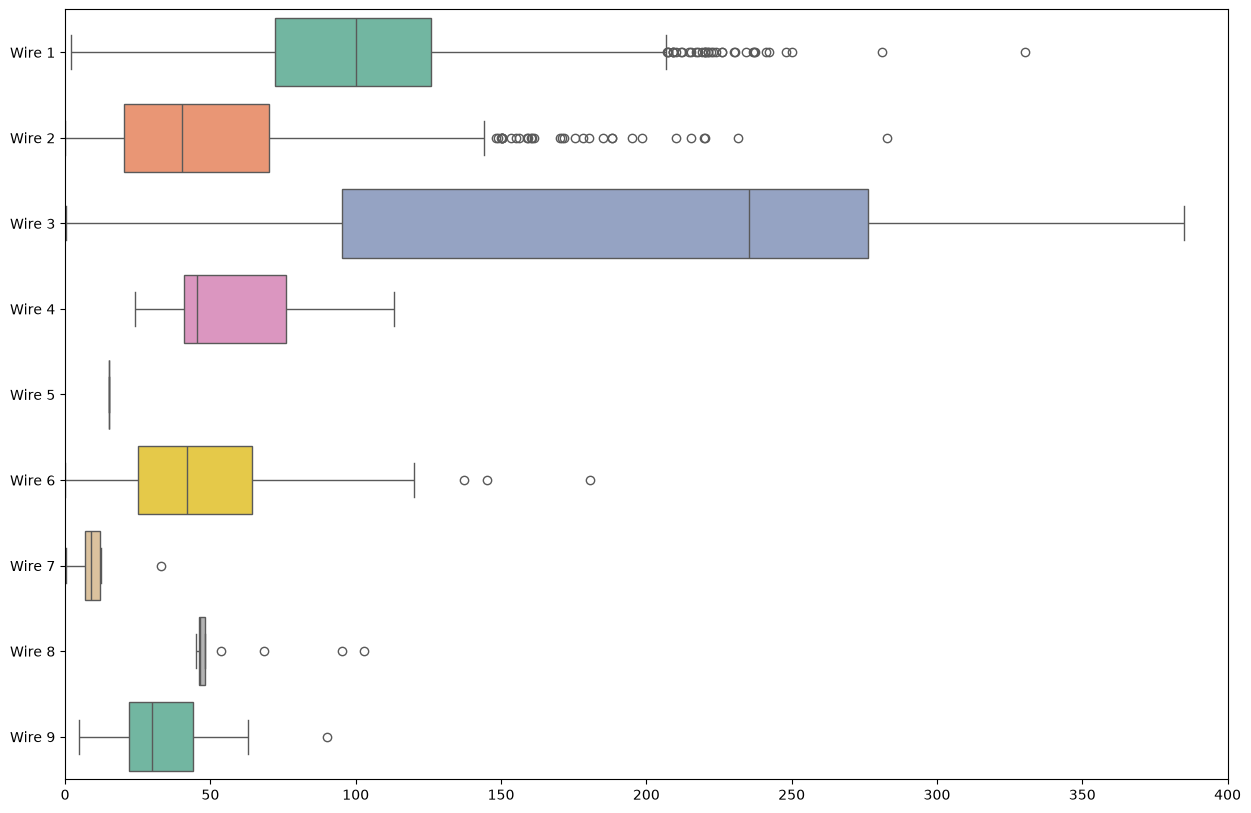

In [41]:
plt.figure(figsize=(15,10))
plt.xlim(0, 400)
sns.boxplot(data=data_wire.drop('key', axis=1), orient="h", palette="Set2")

Видим, что у всех Wire распределения различны.

In [42]:
data_wire = data_wire.fillna(0)

### Изучаем данные по таблице data_wire_time

In [43]:
data_wire_time = load_dataset('data_wire_time_new.csv')
data_wire_time.head()

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,2019-05-03 11:06:19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2019-05-03 11:36:50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2019-05-03 12:11:46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2019-05-03 12:43:22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2019-05-03 13:20:44,2019-05-03 13:15:34,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
pd.Series(data_wire_time['key'].unique()).count()

np.int64(3081)

In [45]:
data_wire_time.info()

<class 'pandas.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   key     3081 non-null   int64
 1   Wire 1  3055 non-null   str  
 2   Wire 2  1079 non-null   str  
 3   Wire 3  63 non-null     str  
 4   Wire 4  14 non-null     str  
 5   Wire 5  1 non-null      str  
 6   Wire 6  73 non-null     str  
 7   Wire 7  11 non-null     str  
 8   Wire 8  19 non-null     str  
 9   Wire 9  29 non-null     str  
dtypes: int64(1), str(9)
memory usage: 240.8 KB


In [46]:
for i in data_wire_time.columns[1:]:    
    data_wire_time = data_wire_time.rename(columns={i:i+'_t'})

In [47]:
for col in data_wire_time.columns[1:]:
    data_wire_time[col] = pd.to_datetime(data_wire_time[col])

In [48]:
data_wire_time.describe()

,key,Wire 1_t,Wire 2_t,Wire 3_t,Wire 4_t,Wire 5_t,Wire 6_t,Wire 7_t,Wire 8_t,Wire 9_t
count,3081.000000,3055,1079,63,14,1,73,11,19,29
mean,1623.426485,2019-07-05 23:22:34.279541,2019-07-07 01:07:08.735866,2019-07-10 15:09:58.650793,2019-07-11 13:44:37,2019-08-13 06:14:30,2019-07-07 11:51:15.095890,2019-08-07 01:16:08.090909,2019-06-23 07:47:49.052631,2019-07-01 11:56:04.793103
min,1.000000,2019-05-03 11:06:19,2019-05-03 13:15:34,2019-05-04 04:34:27,2019-05-07 15:19:17,2019-08-13 06:14:30,2019-05-07 14:46:05,2019-07-27 05:49:05,2019-05-14 11:29:24,2019-05-04 17:21:27
25%,823.000000,2019-06-04 19:30:11.500000,2019-06-05 14:50:26.500000,2019-06-11 14:17:38.500000,2019-07-20 17:58:53.750000,2019-08-13 06:14:30,2019-05-08 21:47:30,2019-07-27 16:27:27,2019-05-14 14:20:07.500000,2019-06-09 19:36:17
50%,1619.000000,2019-07-03 06:36:23,2019-07-04 23:13:39,2019-07-21 10:04:47,2019-07-27 05:45:26.500000,2019-08-13 06:14:30,2019-07-28 05:00:32,2019-08-12 21:48:11,2019-05-14 16:55:09,2019-06-11 10:10:21
75%,2434.000000,2019-08-08 08:56:06.500000,2019-08-08 23:15:17,2019-08-12 22:54:46,2019-07-27 16:20:04.750000,2019-08-13 06:14:30,2019-08-13 13:33:02,2019-08-13 02:02:55.500000,2019-08-16 05:06:53.500000,2019-08-09 06:49:04
max,3241.000000,2019-09-06 17:10:06,2019-09-06 07:35:40,2019-09-02 07:14:44,2019-08-13 03:16:45,2019-08-13 06:14:30,2019-08-18 19:10:56,2019-08-13 10:25:22,2019-08-16 08:56:23,2019-09-03 12:55:23
std,932.996726,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Агрегирование

In [49]:
# суммируем числовые показатели по партии (datetime-столбцы в агрегации не участвуют)
data_arc2 = data_arc.groupby('key').sum(numeric_only=True)
data_arc2.head()

,Активная мощность,Реактивная мощность,diff
key,,,
1,3.036730,2.142821,1098
2,2.139408,1.453357,811
3,4.063641,2.937457,655
4,2.706489,2.056992,741
5,2.252950,1.687991,869


In [50]:
data_temp_first = data_temp.groupby('key').head(1)
data_temp_last = data_temp.groupby('key').tail(1)

data_temp_first.head()

,key,Время замера,Температура
0,1,2019-05-03 11:02:04,1571.0
6,2,2019-05-03 11:34:04,1581.0
11,3,2019-05-03 12:06:44,1596.0
17,4,2019-05-03 12:39:27,1601.0
22,5,2019-05-03 13:11:03,1576.0


In [51]:
data_temp_first = data_temp_first.rename(columns={'Температура':'Температура_нач', 'Время замера':'Время замера_нач'}) #.drop('Время замера', axis=1)
data_temp_last = data_temp_last.rename(columns={'Температура':'Температура_кон', 'Время замера':'Время замера_кон'}) #.drop('Время замера', axis=1)

In [52]:
df = data_arc2.join(data_bulk.set_index('key', drop=True), how='outer')

In [53]:
for i in [data_bulk_time, data_gas, data_temp_first, data_temp_last, data_wire, data_wire_time]:
    i = i.set_index('key', drop=True)
    df = df.join(i, how='outer')  

In [54]:
df.head()

,Активная мощность,Реактивная мощность,diff,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,...,Wire 9,Wire 1_t,Wire 2_t,Wire 3_t,Wire 4_t,Wire 5_t,Wire 6_t,Wire 7_t,Wire 8_t,Wire 9_t
key,,,,,,,,,,,,,,,,,,,,,
1,3.036730,2.142821,1098.0,0.0,0.0,0.0,43.0,0.0,0.0,0.0,...,0.0,2019-05-03 11:06:19,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
2,2.139408,1.453357,811.0,0.0,0.0,0.0,73.0,0.0,0.0,0.0,...,0.0,2019-05-03 11:36:50,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
3,4.063641,2.937457,655.0,0.0,0.0,0.0,34.0,0.0,0.0,0.0,...,0.0,2019-05-03 12:11:46,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
4,2.706489,2.056992,741.0,0.0,0.0,0.0,81.0,0.0,0.0,0.0,...,0.0,2019-05-03 12:43:22,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT
5,2.252950,1.687991,869.0,0.0,0.0,0.0,78.0,0.0,0.0,0.0,...,0.0,2019-05-03 13:20:44,2019-05-03 13:15:34,NaT,NaT,NaT,NaT,NaT,NaT,NaT


In [55]:
time_cols = [col for col in df.columns if pd.api.types.is_datetime64_any_dtype(df[col])]

In [56]:
# оставляем партии, где последний замер температуры был финальным событием
# (после него не было подач материалов/газа/нагрева)
df = df[df[time_cols].max(axis=1) == df['Время замера_кон']]

In [57]:
df = df.drop(columns=time_cols)

<Axes: >

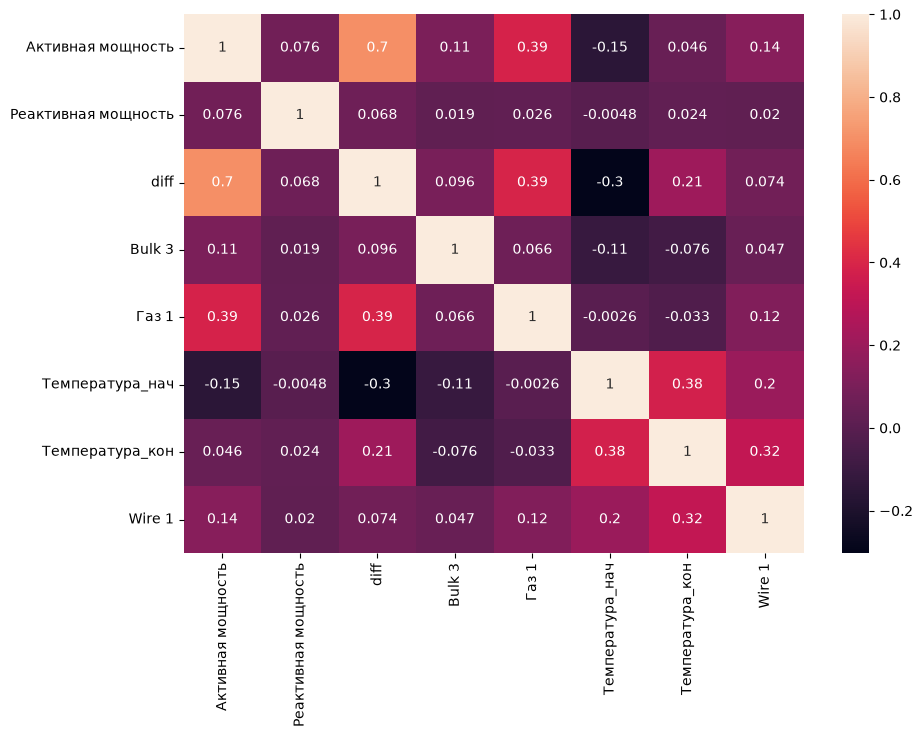

In [58]:
plt.figure(figsize=(10,7))
sns.heatmap(df[['Активная мощность', 'Реактивная мощность',
                'diff', 'Bulk 3', 'Газ 1', 'Температура_нач', 'Температура_кон', 'Wire 1']].corr(), annot=True)


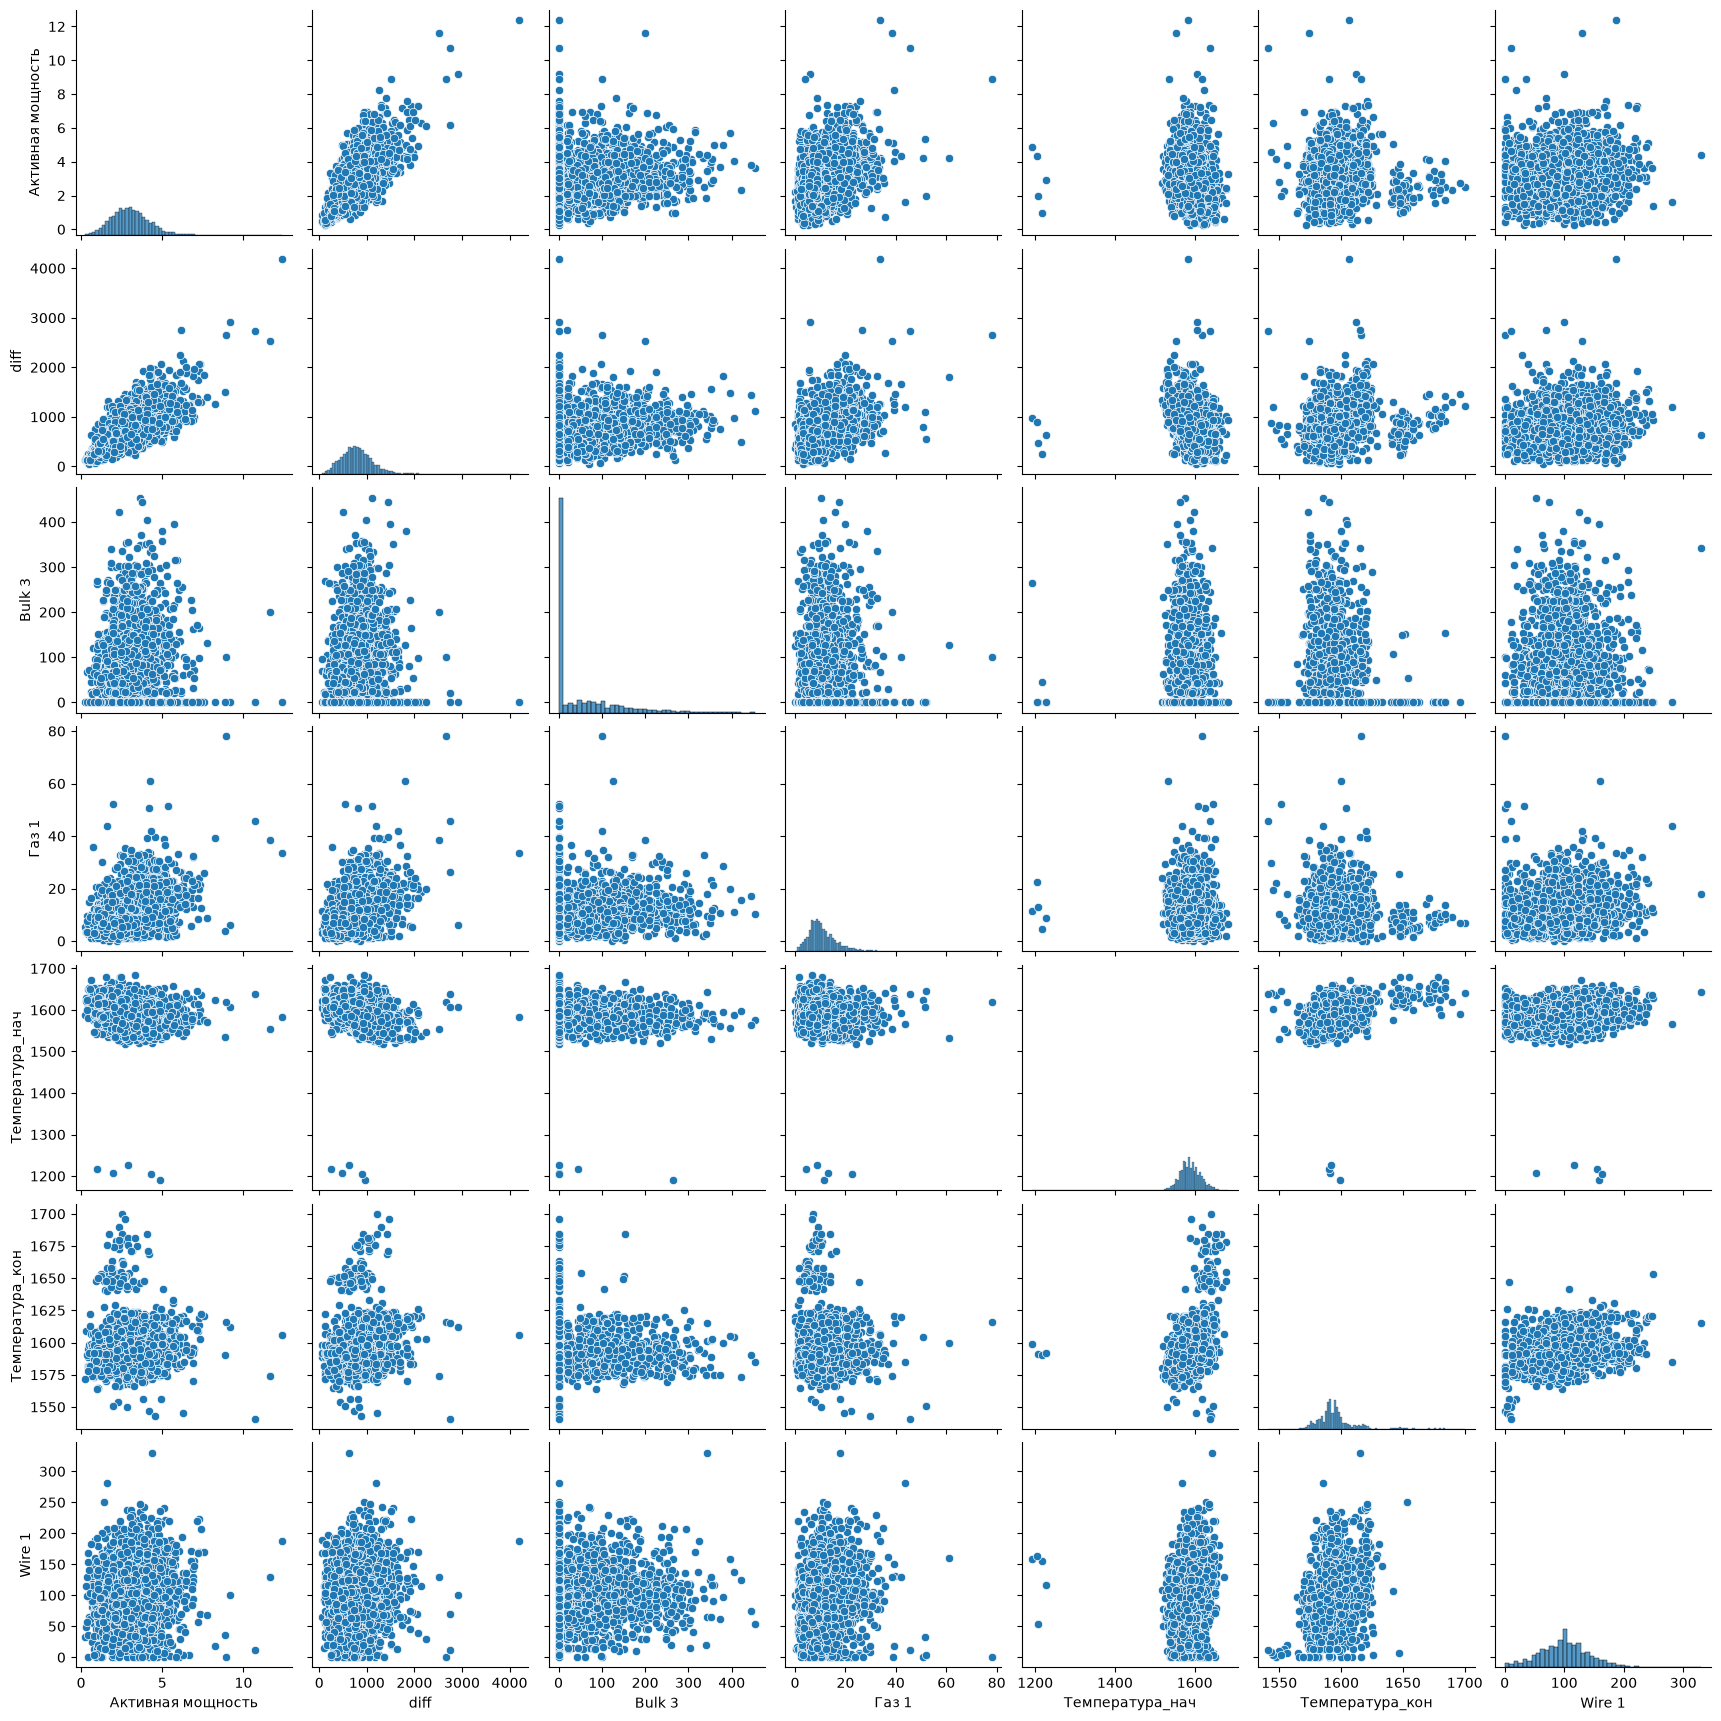

In [59]:
sns.pairplot(df[['Активная мощность',  'diff', 'Bulk 3', 'Газ 1', 'Температура_нач', 'Температура_кон', 'Wire 1']])

Видим, что целевая переменная и начальная температура линейно зависимы. 

Вывод: проведена очистка данных от выбросов, некоторые пропущенные значения заполнены нулями. Данные визуализированы. Таблицы объединены в одну сводную.

## План моделирования

- Удалить значения целевого признака (конечной температуры), если после замера были прочие манипуляции (введение добавок, газа, нагрев) — по временам из разных таблиц.
- Построить различные модели машинного обучения и оценить их качество по метрике MAE (кросс-валидация + отложенная выборка).
- Провести отбор признаков и определить их важность.
- Попробовать модели с разными признаками: активная мощность, время нагрева, полная работа.
- Просуммировать все ресурсы по партии и использовать как новые признаки.
- Выбрать лучшую модель по MAE.

## Обучение на различных наборах признаков

Удаляем всю партию при при удалении пустот в целевой переменной

In [60]:
df = df.dropna(subset=['Температура_кон'])

### Добавляем 2 новых признака: сумма материалов по Bulk и Wire

In [61]:
df['Bulk_total'] =  df[[x for x in df.columns if 'Bulk ' in x]].sum(axis=1)
df['Wire_total'] =  df[[x for x in df.columns if 'Wire ' in x]].sum(axis=1)

In [62]:
df = df.fillna(0)

### Выбор набора признаков
Были опробованы три обучающих набора: с активной мощностью, со временем нагрева в секундах и с «полной работой» (мощность × время). Лучший MAE показал набор с активной мощностью (без реактивной мощности и времени нагрева) — его и используем далее.

In [63]:
X = df.drop(['Температура_кон', 'diff', 'Реактивная мощность'], axis=1)
y = df['Температура_кон']
X.shape, y.shape

((2476, 29), (2476,))

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=12345)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1857, 29), (1857,), (619, 29), (619,))

In [65]:
def evaluate(model, params):
    grid = GridSearchCV(model, param_grid=params, scoring='neg_mean_absolute_error', n_jobs=4, cv=5)
    grid.fit(X_train, y_train)
    pred = grid.predict(X_test)
    print('MAE (CV):', -grid.best_score_)
    print('MAE (test):', mean_absolute_error(y_test, pred))
    print('Best params:', grid.best_params_)

In [66]:
%%time
model = LinearRegression()
evaluate(model, {'fit_intercept': [True, False]})

MAE (CV): 9.461595635107454
MAE (test): 9.555720588896738
Best params: {'fit_intercept': True}
CPU times: user 27.9 ms, sys: 14.5 ms, total: 42.3 ms
Wall time: 1.36 s


In [67]:
%%time
model = RandomForestRegressor(random_state=12345, n_estimators=500, n_jobs=1)
evaluate(model, {'max_depth': list(np.arange(2, 12, 1)) + [None]})

MAE (CV): 7.243266650671134
MAE (test): 7.421116788318885
Best params: {'max_depth': np.int64(10)}
CPU times: user 2.98 s, sys: 71.7 ms, total: 3.06 s
Wall time: 28.9 s


In [68]:
%%time
model = RandomForestRegressor(random_state=12345, n_estimators=500, n_jobs=1)
evaluate(model, {'min_samples_split':np.arange(2, 12, 1)})

MAE (CV): 7.248981541394629
MAE (test): 7.512518185384913
Best params: {'min_samples_split': np.int64(10)}
CPU times: user 3.65 s, sys: 31 ms, total: 3.68 s
Wall time: 42.2 s


In [69]:
%%time
model = RandomForestRegressor(random_state=12345, n_estimators=500, n_jobs=1, min_samples_split=4)
evaluate(model, {'min_samples_leaf':np.arange(1, 30, 10)})

MAE (CV): 7.274243875224515
MAE (test): 7.489449514334143
Best params: {'min_samples_leaf': np.int64(1)}
CPU times: user 3.96 s, sys: 44.4 ms, total: 4.01 s
Wall time: 12.7 s


In [70]:
%%time
model = RandomForestRegressor(random_state=12345, n_estimators=500, n_jobs=1, min_samples_split=4)
evaluate(model, {'max_features': ['sqrt', 'log2', 1.0]})

MAE (CV): 7.268001869219215
MAE (test): 7.331497352234885
Best params: {'max_features': 'sqrt'}
CPU times: user 1.17 s, sys: 26 ms, total: 1.19 s
Wall time: 9.15 s


In [71]:
%%time
model = LGBMRegressor(verbose=-1, n_estimators=300, random_state=12345, n_jobs=1)
evaluate(model, {'learning_rate': np.arange(0.01, 0.31, 0.02)})

MAE (CV): 7.38798383138006
MAE (test): 7.5363600995974895
Best params: {'learning_rate': np.float64(0.01)}
CPU times: user 260 ms, sys: 8.1 ms, total: 268 ms
Wall time: 2.81 s


In [72]:
%%time
model = LGBMRegressor(verbose=-1, n_estimators=300, random_state=12345, n_jobs=1, learning_rate=0.02)
evaluate(model, {'max_depth': list(np.arange(2, 20, 1)) + [None]})

MAE (CV): 7.335500303014557
MAE (test): 7.420357375172925
Best params: {'max_depth': np.int64(3)}
CPU times: user 114 ms, sys: 11.1 ms, total: 125 ms
Wall time: 2.61 s


In [73]:
%%time
model = LGBMRegressor(verbose=-1, random_state=12345, learning_rate=0.02, n_jobs=1, n_estimators=300)
evaluate(model, {'reg_alpha':np.arange(0, 10, 1)})

MAE (CV): 7.402887615234322
MAE (test): 7.573204331049397
Best params: {'reg_alpha': np.int64(5)}
CPU times: user 267 ms, sys: 5.03 ms, total: 272 ms
Wall time: 2.66 s


In [74]:
%%time
model = LGBMRegressor(verbose=-1, n_estimators=300, random_state=12345, learning_rate=0.02, n_jobs=1, reg_alpha=6)
evaluate(model, {'reg_lambda':np.arange(0, 10, 1)})

MAE (CV): 7.38022086823177
MAE (test): 7.542033851277721
Best params: {'reg_lambda': np.int64(4)}
CPU times: user 276 ms, sys: 8.51 ms, total: 284 ms
Wall time: 2.7 s


In [75]:
%%time
model = LGBMRegressor(verbose=-1, n_estimators=300, random_state=12345, learning_rate=0.02, n_jobs=1, reg_alpha=6)
evaluate(model, {'num_leaves': np.arange(10, 30, 2)})

MAE (CV): 7.334879248302943
MAE (test): 7.410064527381242
Best params: {'num_leaves': np.int64(10)}
CPU times: user 145 ms, sys: 3.68 ms, total: 149 ms
Wall time: 1.85 s


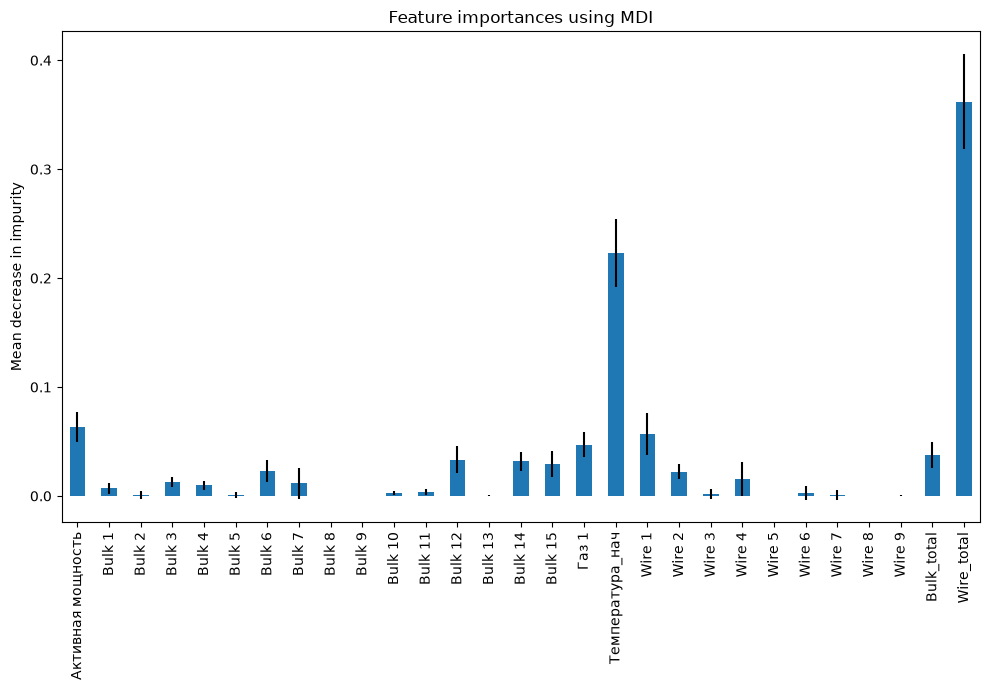

In [76]:
feature_names = X_train.columns
forest = RandomForestRegressor(n_estimators=500, random_state=12345, n_jobs=4)
forest.fit(X_train, y_train)
importances = forest.feature_importances_
forest_importances = pd.Series(importances, index=feature_names)
std = np.std([tree.feature_importances_ for tree in forest.estimators_], axis=0)

fig, ax = plt.subplots(figsize=(10, 7))
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

### Убираем все признаки Bulk 1-15 и Wire 1-9, оставляем фичи Суммарных Bulk и Wire

In [77]:
X = df.drop(['Температура_кон', 'diff'], axis=1)
X = X.drop([x for x in df.columns if 'Bulk ' in x], axis=1)
X = X.drop([x for x in df.columns if 'Wire ' in x], axis=1)
y = df['Температура_кон']
X.shape, y.shape

((2476, 6), (2476,))

In [78]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=12345)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1857, 6), (1857,), (619, 6), (619,))

In [79]:
%%time
model = LinearRegression()
evaluate(model, {'fit_intercept': [True, False]})

MAE (CV): 9.68257948162206
MAE (test): 9.654635268713072
Best params: {'fit_intercept': True}
CPU times: user 13.6 ms, sys: 0 ns, total: 13.6 ms
Wall time: 26.3 ms


In [80]:
%%time
model = RandomForestRegressor(random_state=12345, n_estimators=500, n_jobs=1)
evaluate(model, {'min_samples_split':np.arange(2, 12, 1)})

MAE (CV): 7.693127190722757
MAE (test): 7.821816717323685
Best params: {'min_samples_split': np.int64(8)}
CPU times: user 2.28 s, sys: 31.6 ms, total: 2.31 s
Wall time: 25.2 s


In [81]:
%%time
model = RandomForestRegressor(random_state=12345, n_estimators=500, n_jobs=1, min_samples_split=7)
evaluate(model, {'min_samples_leaf':np.arange(1, 30, 10)})

MAE (CV): 7.700733918209954
MAE (test): 7.824512286626502
Best params: {'min_samples_leaf': np.int64(1)}
CPU times: user 2.19 s, sys: 3.52 ms, total: 2.19 s
Wall time: 7.58 s


In [82]:
%%time
model = LGBMRegressor(verbose=-1, n_estimators=100, random_state=12345, n_jobs=1)
evaluate(model, {'learning_rate': np.arange(0.01, 0.31, 0.02)})

MAE (CV): 7.91370093057277
MAE (test): 7.8439810695806464
Best params: {'learning_rate': np.float64(0.03)}
CPU times: user 85.6 ms, sys: 3.67 ms, total: 89.3 ms
Wall time: 754 ms


In [83]:
%%time
model = LGBMRegressor(verbose=-1, random_state=12345, learning_rate=0.06, n_jobs=1, n_estimators=100)
evaluate(model, {'reg_alpha': np.arange(0, 20, 2)})

MAE (CV): 7.970577625499307
MAE (test): 7.971428986477115
Best params: {'reg_alpha': np.int64(18)}
CPU times: user 91 ms, sys: 94 μs, total: 91.1 ms
Wall time: 672 ms


In [84]:
%%time
model = LGBMRegressor(verbose=-1, n_estimators=100, random_state=12345, learning_rate=0.04, n_jobs=1)
evaluate(model, {'reg_lambda':np.arange(0, 50, 5)})

MAE (CV): 7.866260272902967
MAE (test): 7.86634061932513
Best params: {'reg_lambda': np.int64(5)}
CPU times: user 74.7 ms, sys: 4.05 ms, total: 78.8 ms
Wall time: 534 ms


In [85]:
%%time
model = LGBMRegressor(verbose=-1, n_estimators=100, random_state=12345, learning_rate=0.04, n_jobs=1)
evaluate(model, {'num_leaves': np.arange(2, 60, 4)})

MAE (CV): 7.78798811203839
MAE (test): 7.74171982167097
Best params: {'num_leaves': np.int64(6)}
CPU times: user 69.3 ms, sys: 0 ns, total: 69.3 ms
Wall time: 695 ms


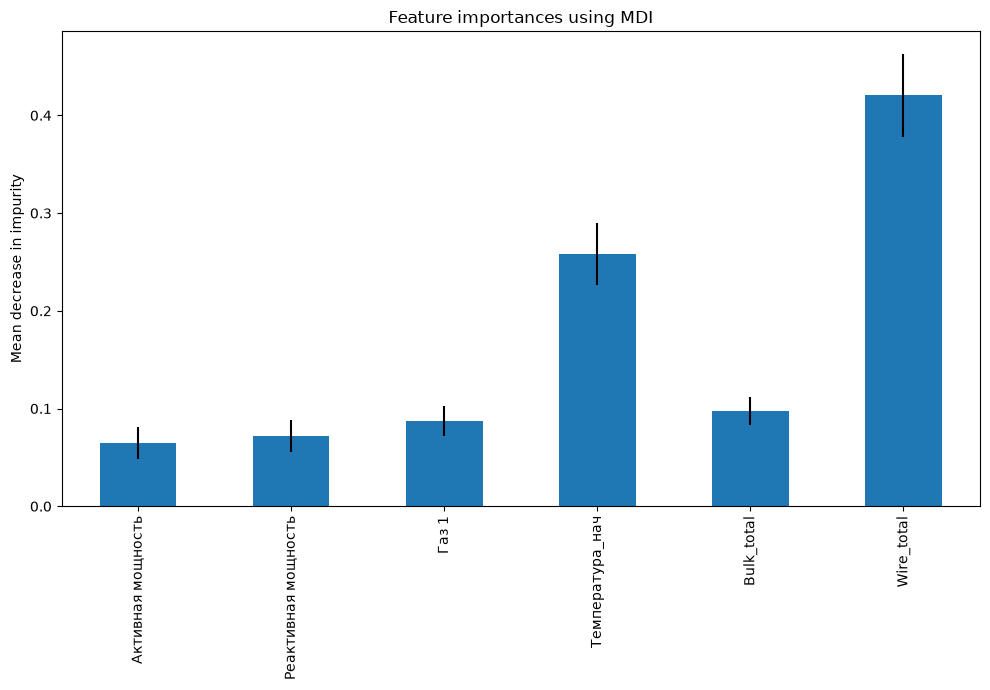

In [86]:
feature_names = X_train.columns
forest = RandomForestRegressor(n_estimators=500, random_state=12345, n_jobs=4)
forest.fit(X_train, y_train)
importances = forest.feature_importances_
forest_importances = pd.Series(importances, index=feature_names)
std = np.std([tree.feature_importances_ for tree in forest.estimators_], axis=0)

fig, ax = plt.subplots(figsize=(10, 7))
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

In [87]:
%%time
from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS

model = RandomForestRegressor(n_estimators=100, random_state=12345, n_jobs=4)
efs1 = EFS(model,
           min_features=1,
           max_features=6,
           scoring='neg_mean_absolute_error',
           print_progress=True,
           cv=5)
efs1 = efs1.fit(X, y)

print('Best MAE: %.2f' % -efs1.best_score_)
print('Best subset (indices):', efs1.best_idx_)
print('Best subset (corresponding names):', efs1.best_feature_names_)

Features: 1/63

Features: 2/63

Features: 3/63

Features: 4/63

Features: 5/63

...

Features: 60/63

Features: 61/63

Features: 62/63

Features: 63/63

Best MAE: 7.93
Best subset (indices): (0, 1, 2, 3, 4, 5)
Best subset (corresponding names): ('Активная мощность', 'Реактивная мощность', 'Газ 1', 'Температура_нач', 'Bulk_total', 'Wire_total')
CPU times: user 1min 51s, sys: 2.18 s, total: 1min 53s
Wall time: 41.8 s


## Модели на очищенных от выбросов данных

In [88]:
df2 = filt(0.035, 0.995, df, [i for i in df.drop(['Температура_кон'], axis=1).columns[1:]])
#df2 = filt(0, 0.99, df, [i for i in df.columns[1:]])

In [89]:
X = df2.drop(['Температура_кон', 'Реактивная мощность', 'diff'], axis=1)
y = df2['Температура_кон']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=12345)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1319, 29), (1319,), (440, 29), (440,))

In [90]:
%%time
model = LinearRegression()
evaluate(model, {'fit_intercept': [True, False]})

MAE (CV): 6.6873537606403115
MAE (test): 6.8109390143082615
Best params: {'fit_intercept': True}
CPU times: user 18 ms, sys: 3.93 ms, total: 21.9 ms
Wall time: 39.2 ms


In [91]:
%%time
model = LGBMRegressor(verbose=-1, n_estimators=100, random_state=12345, n_jobs=1)
evaluate(model, {'learning_rate': np.arange(0.01, 0.31, 0.02)})

MAE (CV): 6.632425362850254
MAE (test): 6.647082190824227
Best params: {'learning_rate': np.float64(0.03)}
CPU times: user 171 ms, sys: 4.26 ms, total: 175 ms
Wall time: 886 ms


In [92]:
%%time
model = LGBMRegressor(verbose=-1, n_estimators=100, random_state=12345, learning_rate=0.03, n_jobs=1)
evaluate(model, {'num_leaves': np.arange(2, 60, 4)})

MAE (CV): 6.51675540928556
MAE (test): 6.604048051445642
Best params: {'num_leaves': np.int64(10)}
CPU times: user 87.6 ms, sys: 3.8 ms, total: 91.4 ms
Wall time: 796 ms


In [93]:
%%time
model = RandomForestRegressor(random_state=12345, n_estimators=500, n_jobs=1)
evaluate(model, {'max_depth': list(np.arange(2, 12, 1)) + [None]})

MAE (CV): 6.566556319470521
MAE (test): 6.717681276163816
Best params: {'max_depth': np.int64(6)}
CPU times: user 1.48 s, sys: 3.8 ms, total: 1.48 s
Wall time: 19.5 s


In [94]:
%%time
model = RandomForestRegressor(random_state=12345, n_estimators=500, n_jobs=1)
evaluate(model, {'min_samples_split':np.arange(2, 12, 1)})

MAE (CV): 6.632140429364513
MAE (test): 6.775568761797575
Best params: {'min_samples_split': np.int64(11)}
CPU times: user 2.19 s, sys: 8.37 ms, total: 2.2 s
Wall time: 25.6 s


In [95]:
%%time
model = RandomForestRegressor(random_state=12345, n_estimators=500, n_jobs=1, min_samples_split=9)
evaluate(model, {'min_samples_leaf':np.arange(1, 30, 10)})

MAE (CV): 6.578505312699957
MAE (test): 6.730787214237996
Best params: {'min_samples_leaf': np.int64(11)}
CPU times: user 1.52 s, sys: 16.1 ms, total: 1.53 s
Wall time: 6.67 s


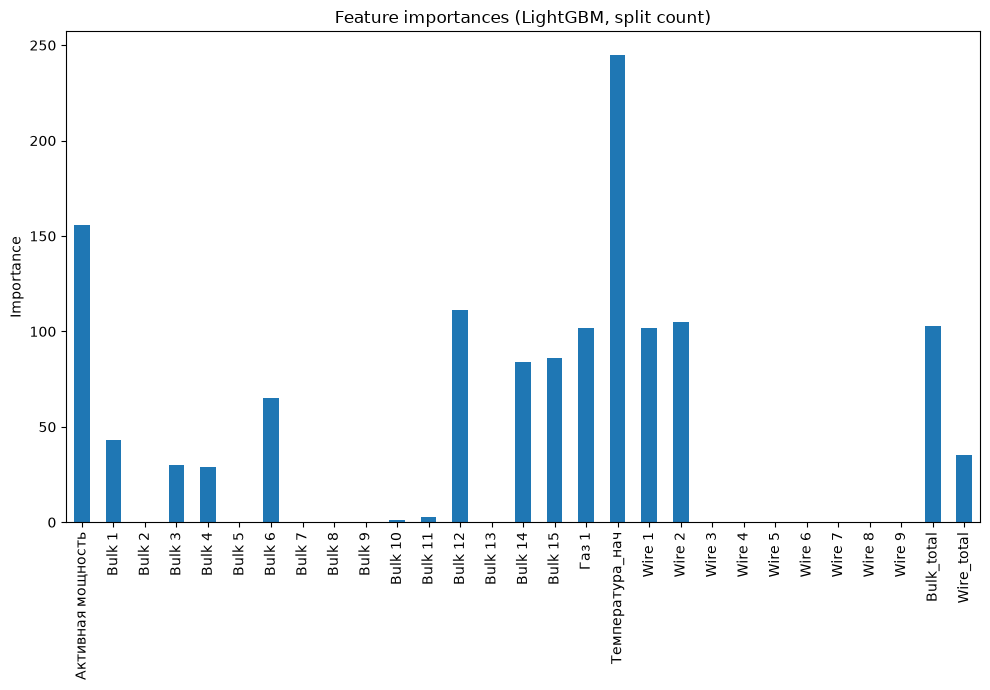

In [96]:
feature_names = X_train.columns
booster = LGBMRegressor(n_estimators=100, random_state=12345, learning_rate=0.03, num_leaves=14, n_jobs=4, verbose=-1)
booster.fit(X_train, y_train)
booster_importances = pd.Series(booster.feature_importances_, index=feature_names)

fig, ax = plt.subplots(figsize=(10, 7))
booster_importances.plot.bar(ax=ax)
ax.set_title("Feature importances (LightGBM, split count)")
ax.set_ylabel("Importance")
fig.tight_layout()

- Самыми важными признаками в лучшей модели являются Активная мощность, Температура начальная по партии, Bulk_6, Wire_1, Газ_1.

## Дополнительные модели

<Axes: xlabel='Температура_нач', ylabel='Count'>

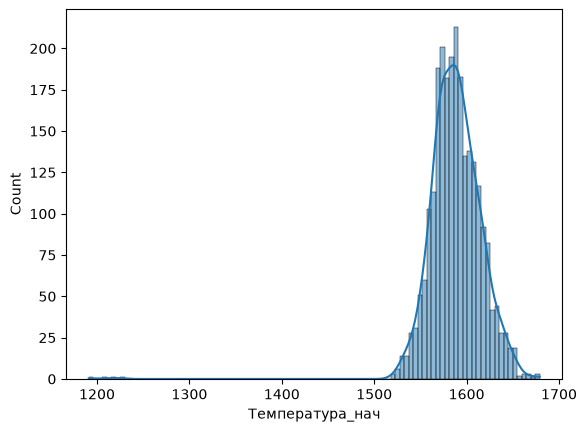

In [97]:
sns.histplot(df['Температура_нач'], kde=True)

In [98]:
#Создадим новый признак: по диапазонам начальной температуры
df2['Temp_type'] = df2['Температура_нач'].apply(lambda x: 0 if x<1575 or x>1660
                                                      else 1)

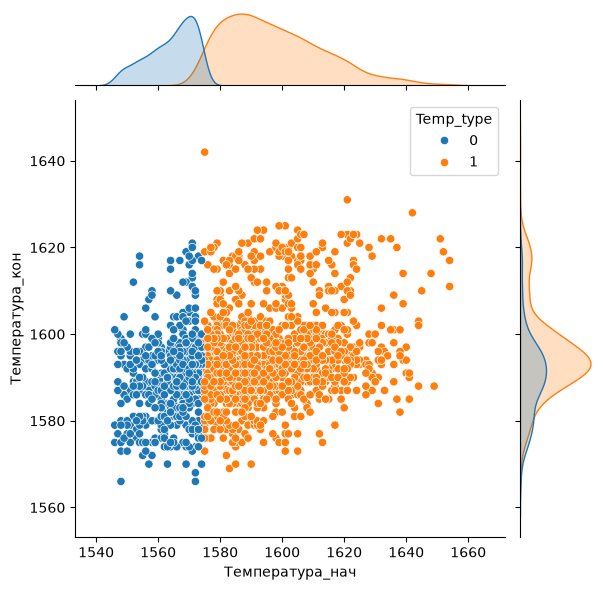

In [99]:
sns.jointplot(data=df2, x="Температура_нач", y="Температура_кон", hue='Temp_type') 

In [100]:
X = df2.drop(['Температура_кон', 'Температура_нач',  'Реактивная мощность', 'diff'], axis=1)
y = df2['Температура_кон']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=12345)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1319, 29), (1319,), (440, 29), (440,))

In [101]:
%%time
model = LinearRegression()
evaluate(model, {'fit_intercept': [True, False]})

MAE (CV): 6.772911144383015
MAE (test): 6.810468334255314
Best params: {'fit_intercept': True}
CPU times: user 6.38 ms, sys: 11.9 ms, total: 18.3 ms
Wall time: 26.7 ms


In [102]:
%%time
model = RandomForestRegressor(random_state=12345, n_estimators=500, n_jobs=1)
evaluate(model, {'min_samples_split':np.arange(2, 12, 1)})

MAE (CV): 6.792568628415817
MAE (test): 6.818507831255834
Best params: {'min_samples_split': np.int64(11)}
CPU times: user 2.15 s, sys: 11.7 ms, total: 2.16 s
Wall time: 24.4 s


In [103]:
%%time
model = LGBMRegressor(verbose=-1, n_estimators=100, random_state=12345, learning_rate=0.03, n_jobs=1)
evaluate(model, {'num_leaves': np.arange(2, 60, 4)})

MAE (CV): 6.619729708987717
MAE (test): 6.7400792919394
Best params: {'num_leaves': np.int64(6)}
CPU times: user 82 ms, sys: 8.35 ms, total: 90.3 ms
Wall time: 735 ms


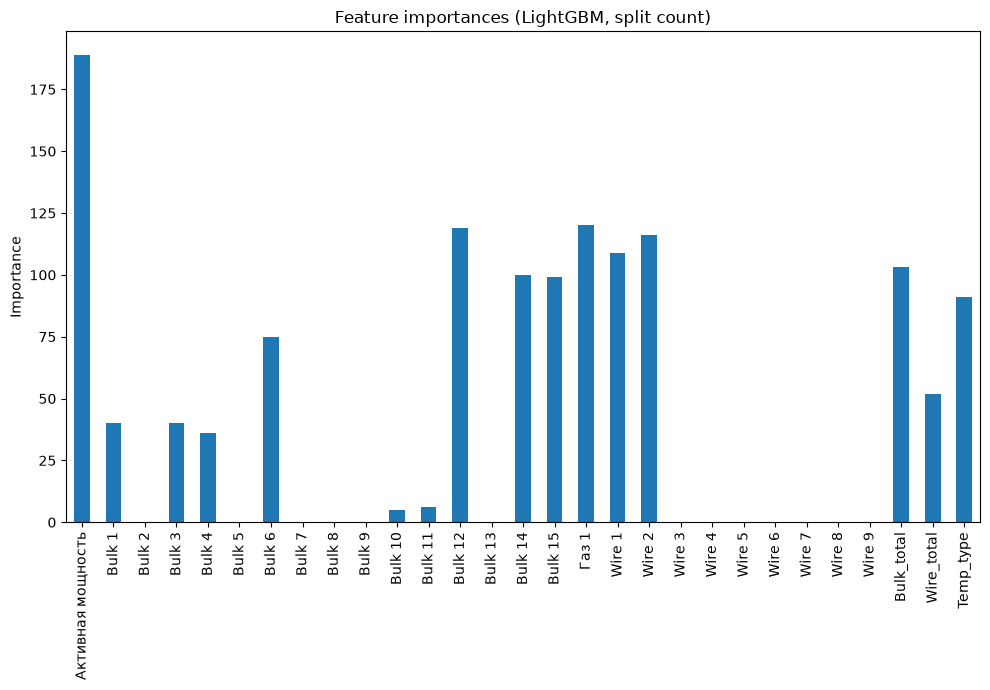

In [104]:
feature_names = X_train.columns
booster = LGBMRegressor(n_estimators=100, random_state=12345, learning_rate=0.03, num_leaves=14, n_jobs=4, verbose=-1)
booster.fit(X_train, y_train)
booster_importances = pd.Series(booster.feature_importances_, index=feature_names)

fig, ax = plt.subplots(figsize=(10, 7))
booster_importances.plot.bar(ax=ax)
ax.set_title("Feature importances (LightGBM, split count)")
ax.set_ylabel("Importance")
fig.tight_layout()

## Визуализация с TSNE очищенного от выбросов датафрейма (раскраска по диапазону начальной температуры)

In [105]:
%%time
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

tsne = TSNE(random_state=17)
tsne_representation = tsne.fit_transform(X_scaled)

CPU times: user 9.04 s, sys: 17.1 ms, total: 9.06 s
Wall time: 2.32 s


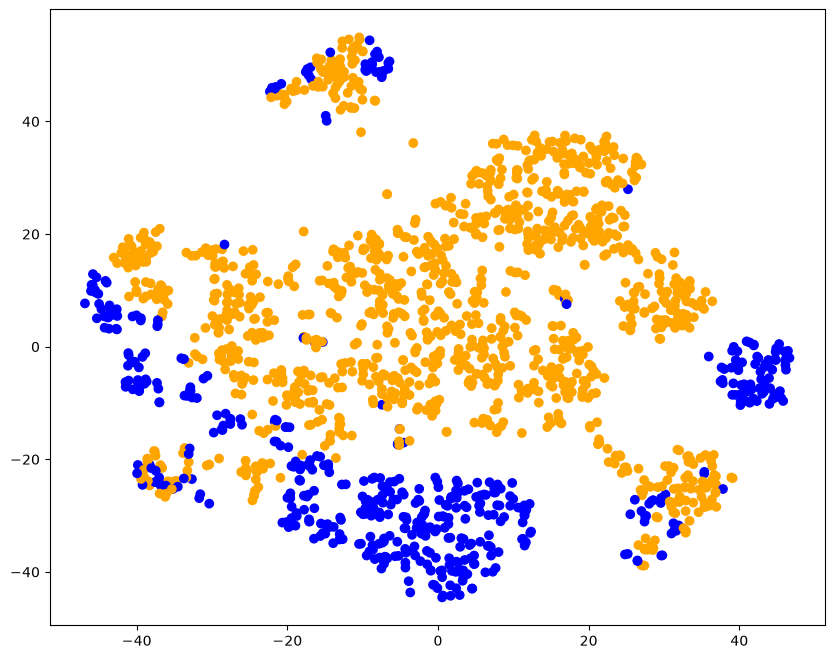

In [106]:
#смотрим где кучкуются признаки, разбитые по диапазонам начальной температуры
plt.figure(figsize=(10,8))
plt.scatter(tsne_representation[:, 0], tsne_representation[:, 1], 
            c=df2['Temp_type'].map({0: 'blue', 1: 'orange'}));

## Визуализация с TSNE неочищенного от выбросов датафрейма (раскраска по диапазону конечной температуры)

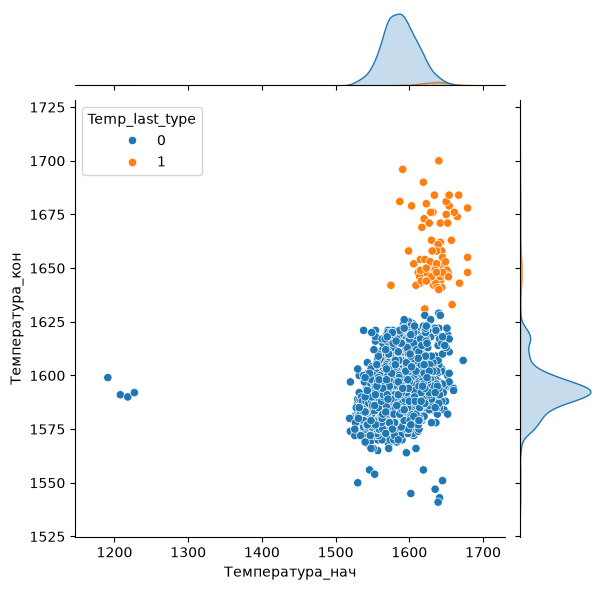

In [107]:
#Создадим новый признак: по диапазонам конечной температуры
df['Temp_last_type'] = df['Температура_кон'].apply(lambda x: 0 if x<1630
                                                      else 1)
sns.jointplot(data=df, x="Температура_нач", y="Температура_кон", hue='Temp_last_type')

In [108]:
X = df.drop(['Температура_кон', 'diff', 'Реактивная мощность'], axis=1)
X_scaled = scaler.fit_transform(X)

tsne = TSNE(random_state=17)
tsne_representation = tsne.fit_transform(X_scaled)

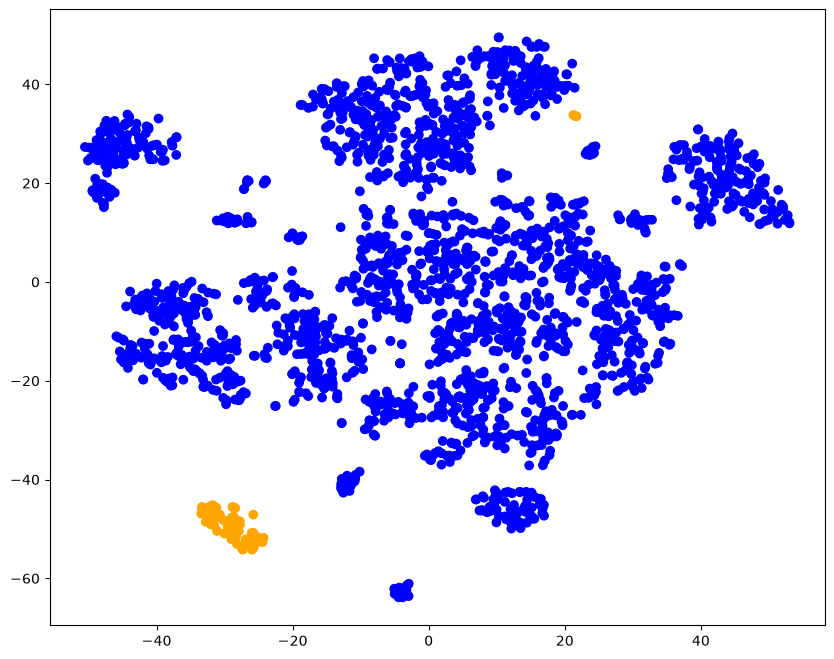

In [109]:
#смотрим где кучкуются признаки, разбитые по диапазонам конечной температуры
plt.figure(figsize=(10,8))
plt.scatter(tsne_representation[:, 0], tsne_representation[:, 1], 
            c=df['Temp_last_type'].map({0: 'blue', 1: 'orange'}));

## Вывод:
Лучший результат — **LightGBM на очищенных от выбросов данных: MAE = 6.60 на отложенной выборке** (6.52 на кросс-валидации; гиперпараметры: learning_rate=0.03, num_leaves=10). Random Forest на тех же данных даёт MAE 6.72–6.78, линейная регрессия — 6.81.

Дополнительно построены модели, в которых вместо начальной температуры используется факт попадания в эмпирически выбранный диапазон (признак `Temp_type`): лучшая из них (LightGBM) даёт MAE 6.74 и почти не уступает основной. Также выполнена визуализация t-SNE для анализа структуры данных.

### В результате работы над проектом:
- Проведён исследовательский анализ семи исходных таблиц, по его итогам составлен план моделирования;
- Удалены некорректные значения целевого признака (партии, где после последнего замера температуры продолжались манипуляции — фильтрация по временам событий из разных таблиц);
- Просуммированы ресурсы по партии (Bulk_total, Wire_total) и использованы как новые признаки;
- Построены и сравнены модели (LinearRegression, RandomForest, LightGBM) на нескольких наборах признаков, качество оценено по MAE на кросс-валидации и на отложенной выборке;
- Проведён отбор признаков (в т.ч. полный перебор подмножеств EFS) и определена их важность: топ-признаки — начальная температура, активная мощность, суммарные объёмы материалов;
- Реактивная мощность и «полная работа» не улучшили качество, поэтому в финальный набор признаков не вошли;
- **Итоговая модель — LightGBM на очищенных от выбросов данных, MAE = 6.60 на отложенной выборке.** Модель поможет предприятию оптимизировать энергопотребление на этапе обработки стали.